### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

Using TensorFlow backend.


In [3]:
tf.__version__

'1.14.0'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Collect Data

In [0]:
import keras

In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 1s 0us/step


In [5]:
print(testY[0:5])

[9 2 1 1 6]


In [6]:
print('trainY = ',trainY.shape)
print('testY = ',testY.shape )

trainY =  (60000,)
testY =  (10000,)


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
from keras.utils import to_categorical
from keras.utils import np_utils 

In [0]:
import numpy as np
trainY= to_categorical(trainY, num_classes=len(np.unique(trainY)))
testY= to_categorical(testY, num_classes=len(np.unique(testY)))

#Encoding the output class label (One-Hot Encoding)
#y_train=np_utils.to_categorical(ytrain,10)
#y_test=np_utils.to_categorical(ytest,10)
#trainY[2]


In [10]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])
print(trainX.shape)

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(60000, 28, 28)


### Visualize the data

Plot first 10 images in the triaining set and their labels.

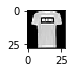

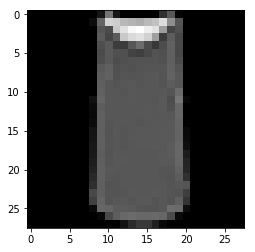

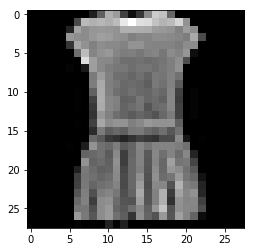

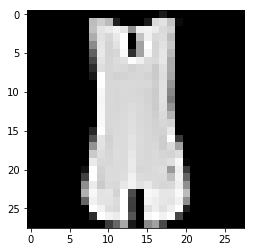

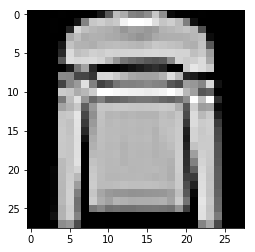

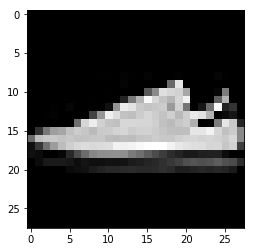

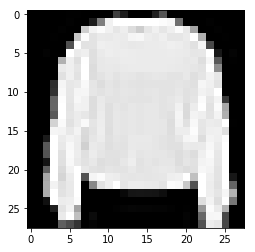

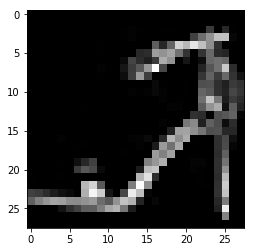

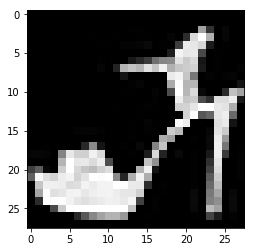

In [9]:
#for i in range(0,9):
#plt.imshow(trainX[0:2,:],cmap='gray')

w=10
h=10
fig=plt.figure(figsize=(8, 8))
columns = 10
rows = 1
for i in range(1, columns*rows):
    img = trainX[i,:]
    fig.add_subplot(rows, columns, i)
    plt.imshow(img,cmap='gray')
    plt.show()
    
#print(testX[0:10])

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [20]:
#from keras.models import Sequential
#from keras.layers import Dense

#Initialize Sequential Graph (model)
#model = tf.keras.Sequential()

#Normalize input data
#model.add(tf.keras.layers.Dense(10, input_shape=(4,), activation='softmax'))

#Compile the model - add Loss and Gradient Descent optimizer
#model.compile(optimizer='sgd', loss='categorical_crossentropy')

W0728 16:00:33.805290 140114012940160 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [14]:
trainX.shape

(60000, 28, 28)

In [0]:
#(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

# reshape images to specify that it's a single channel
trainX = trainX.reshape(trainX.shape[0], 28, 28,1)
testX = testX.reshape(testX.shape[0], 28, 28,1)
trainX = trainX.astype('float32')
testX = testX.astype('float32')
trainX /= 255
testX /= 255

# Convert 1-dimensional class arrays to 10-dimensional class matrices
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

#trainY = trainY.reshape(trainY.shape[0],10)
#testY = testY.reshape(testY.shape[0], 10)

In [11]:
print(trainX.shape)
print(testX.shape)
print(trainY.shape)
print(testY.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000, 10, 10)
(10000, 10, 10)


In [12]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))

W0728 18:35:15.652736 139841121552256 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  
W0728 18:35:15.660775 139841121552256 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 18:35:15.674100 139841121552256 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.



In [20]:
model.add(MaxPooling2D(pool_size=(3,3)))

W0728 18:31:53.566453 139794539407232 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3976: The name tf.nn.max_pool is deprecated. Please use tf.nn.max_pool2d instead.



In [0]:
model.add(Flatten())

In [0]:
model.add(Dense(128,activation='relu'))

In [0]:
model.add(Dense(10,activation='softmax'))

In [24]:
model.compile(optimizer="sgd", loss='categorical_crossentropy', metrics=['accuracy'])

W0728 18:32:10.157914 139794539407232 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0728 18:32:10.193933 139794539407232 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3295: The name tf.log is deprecated. Please use tf.math.log instead.



In [15]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten


model = keras.Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
# compile model
model.compile(optimizer="sgd", loss='categorical_crossentropy', metrics=['accuracy'])

W0728 18:37:09.988467 139841121552256 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0728 18:37:10.013850 139841121552256 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3295: The name tf.log is deprecated. Please use tf.math.log instead.



### Execute the model using model.fit()

In [16]:
model.fit(trainX,trainY,batch_size=10,nb_epoch=12,verbose=1,validation_data=(testX,testY))
#history = model.fit(trainX, trainY, epochs=12, batch_size=10, validation_data=(testX, testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


ValueError: ignored

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [0]:
from keras.layers import  BatchNormalization
  
model.add(BatchNormalization(axis=-1))

### Execute the model

In [0]:
model.compile(optimizer="sgd", loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras.optimizers import SGD
sgd = SGD(lr=0.001)

In [0]:
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
history= model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model = keras.Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))
# compile model
sgd = SGD(lr=0.03)
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
print(model.summary())

In [0]:
history = model.fit(trainX, trainY, epochs=epoch_n, batch_size=10, validation_data=(testX, testY))

## Review model

### Run the model